<a href="https://colab.research.google.com/github/bberrium/Picsart-Academy/blob/main/Phase%203/DS/notebooks/Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [4]:
class0_len = 1000
X0 = np.random.normal((0,1,2), (1,2,2), (class0_len,3)) # np.random.normal(loc, scale, size) loc:mean, scale:std
y0 = [0]*class0_len

class1_len = 2000
X1 = np.random.normal((1,1,-1), (3,1,1), (class1_len, 3))
y1 = [1]*class1_len

In [5]:
X = np.concatenate((X0, X1))
y = y0+y1

In [6]:
y = np.array(y)

shuffled_indices = np.random.permutation(len(X))
X = X[shuffled_indices]
y = y[shuffled_indices]

In [7]:
pd.DataFrame(X).head()

,0,1,2
0,1.675572,0.548791,4.235818
1,3.727420,1.493809,-0.698102
2,3.197877,2.052106,-2.635299
3,3.878452,0.275256,0.047620
4,1.574143,0.977419,-2.537787


In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=24)

In [9]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print(gnb.score(X_train, y_train))
print(gnb.score(X_val, y_val))

0.9231111111111111
0.92


In [10]:
point = [[2.5, 1, 1.8]]
prediction = gnb.predict(point)
print(prediction)

[1]


In [11]:
def perf_measure(y_actual, y_hat):
    y_actual = np.array(y_actual)
    y_hat = np.array(y_hat)
    tp = np.sum((y_actual==1) & (y_hat==1))
    fp = np.sum((y_actual==0) & (y_hat==1))
    tn = np.sum((y_actual==0) & (y_hat==0))
    fn = np.sum((y_actual==1) & (y_hat==0))
    return tp, fp, tn, fn

In [12]:
tp, fp, tn, fn = perf_measure(y_val, gnb.predict(X_val))

In [13]:
tp, fp, tn, fn

(np.int64(484), np.int64(44), np.int64(206), np.int64(16))

In [14]:
def print_metrics(tp, fp, tn, fn):
    print('Accuracy:', (tp + tn) / (tp + tn + fn + fp))

lets try to find drawbacks here

In [15]:
print_metrics(tp=950, fp=10, tn=40, fn=50)

Accuracy: 0.9428571428571428


## HOMEWORK: think of example when all metrics are high, but model is bad

In [16]:
#suppose we want to predict if an asteroid coming from the space hits the earth or not, and there are 10000 asteroids flying towards earth and
#only 1 of them is a 'killer' asteroid, the other 9999 are safe. And we have a lazy model that predicts that all the asteroids are safe (are zeros).
#so we get a 99% accuracy but we dont predict that one only 'killer' asteroid correctly.

y_actual = np.array([0]*9999 + [1])
y_hat = np.zeros(10000)

tp = np.sum((y_actual==1) & (y_hat==1))
fp = np.sum((y_actual==0) & (y_hat==1))
tn = np.sum((y_actual==0) & (y_hat==0))
fn = np.sum((y_actual==1) & (y_hat==0))

accuracy = (tp + tn) / (tp + tn + fn + fp)
print(accuracy)

0.9999


# F1-Score

<img src="https://github.com/bberrium/Picsart-Academy/blob/main/Phase%203/DS/notebooks/f1score.png?raw=1">

In [17]:
print('F1-Score: ', (tp)/(tp+(fp+fn)/2))

F1-Score:  0.0


# ROC Curve, AUC

<img src="https://github.com/bberrium/Picsart-Academy/blob/main/Phase%203/DS/notebooks/roc_curve.jpeg?raw=1">

In [18]:
fpr = fp/(fp+tn)
tpr = tp/(tp+fn)

In [19]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

In [30]:
# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=1)
# split into train/test sets
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2)

In [34]:
# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainy)
# predict probabilities
print(testX[:8])
lr_probs = model.predict_proba(testX)
print(lr_probs[:8])
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
print("\n============positive outcome===============\n")
print(lr_probs[:8])


[[-2.83845485 -4.41301197 -1.48600518  3.82977455 -0.08170227]
 [ 0.28233354  0.28435329 -0.08565427 -0.40898715 -0.53670542]
 [-0.41565942 -0.1753093   0.49355502  0.64627039  1.16258855]
 [ 0.93850795  1.6919579   0.84295055 -1.22403293  0.18622375]
 [ 0.18189192  1.48445673  1.9099058  -0.02739032 -2.04115418]
 [-0.94285783 -2.08966246 -1.43560389  1.15897065 -0.5072572 ]
 [ 2.44148888  2.36359023 -0.88471179 -3.55403294 -1.2671073 ]
 [ 0.45465286  1.08370034  0.8071046  -0.54506574 -2.31661731]]
[[0.9212648  0.0787352 ]
 [0.56740869 0.43259131]
 [0.3595957  0.6404043 ]
 [0.22847725 0.77152275]
 [0.01831759 0.98168241]
 [0.93361594 0.06638406]
 [0.88888625 0.11111375]
 [0.13498872 0.86501128]]

============positive outcome===============

[0.0787352  0.43259131 0.6404043  0.77152275 0.98168241 0.06638406
 0.11111375 0.86501128]


In [40]:
# calculate score
lr_auc = roc_auc_score(testy, lr_probs)
# summarize score
print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curve
lr_fpr, lr_tpr = roc_curve(testy, lr_probs)

Logistic: ROC AUC=0.933


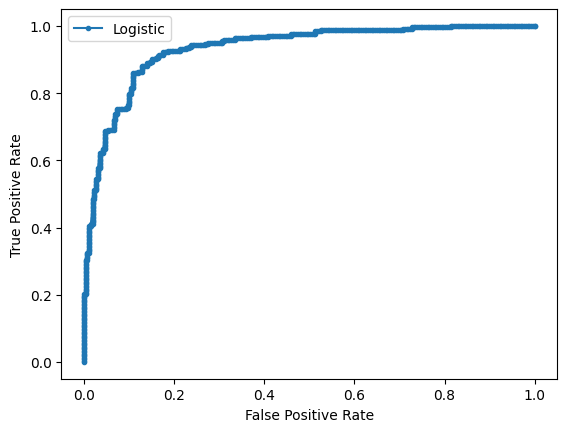

In [41]:
# plot the roc curve for the model
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

implement roc_auc_score and roc_curve functions on your own

In [39]:
def roc_curve(testy, lr_probs):
    thresholds = np.unique(lr_probs)
    tprs = []
    fprs = []

    for threshold in thresholds:
        y_hat = (lr_probs >= threshold).astype(int)

        tp = np.sum((testy == 1) & (y_hat == 1))
        fp = np.sum((testy == 0) & (y_hat == 1))
        tn = np.sum((testy == 0) & (y_hat == 0))
        fn = np.sum((testy == 1) & (y_hat == 0))

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        tprs.append(tpr)
        fprs.append(fpr)

    # Add (0,0) and (1,1) points for a complete curve
    fprs.insert(0, 0)
    tprs.insert(0, 0)
    fprs.append(1)
    tprs.append(1)

    # Sort by FPR
    sorted_indices = np.argsort(fprs)
    fprs = np.array(fprs)[sorted_indices]
    tprs = np.array(tprs)[sorted_indices]

    return fprs, tprs

def roc_auc_score(testy, lr_probs):
    fprs, tprs = roc_curve(testy, lr_probs)
    # Sort the FPRs and TPRs to ensure correct area calculation
    sorted_indices = np.argsort(fprs)
    fprs = fprs[sorted_indices]
    tprs = tprs[sorted_indices]
    auc = np.trapezoid(tprs, fprs)
    return auc

In [42]:
def roc_curve(testy, lr_probs):
    thresholds = np.unique(lr_probs)
    tprs = np.array()
    fprs = np.array()

    for threshold in thresholds:
      y_hat = np.array(lr_probs >= threshold)
      tp = np.sum((testy == 1) & (lr_probs == 1))
      tn = np.sum((testy == 0) & (lr_probs == 0))
      fp = np.sum((testy== 1) & (lr_probs == 0))
      tn = np.sum((testy == 0) & (lr_probs == 0))

      fpr = fp / (fp+tn) if (fp+tn)>0 else 0
      tpr = tp / (fp+fn) if (fp+fn)>0 else 0

      fprs.append(fpr)
      tprs.apend(tpr)

    fpr.insert(0,0)
    tpr.insert(0,0)
    tpr.append(1)
    fpr.append(1)

    sorted_idx = np.argsort(fprs)
    fprs = fprs[sorted_idx]
    tprs = tprs[sorted_idx]

    return fprs, tprs

def roc_auc_score(testy, lr_probs):
    fprs, tprs = roc_curve(testy, lr_probs)
    sorted_idx = np.argsort(fprs)
    fprs = fprs[sorted_idx]
    tprs = tprs[sorted_idx]
    auc = np.trapezoid(tprs, fprs)

    return auc